# Topic Modeling: Latent Dirichlet Allocation with gensim

Gensim is a specialized NLP library with a fast LDA implementation and many additional features. We will also use it in the next chapter on word vectors (see the notebook lda_with_gensim for details.

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from pathlib import Path
import pandas as pd

# Visualization
import seaborn as sns
import pyLDAvis

# sklearn for feature extraction & modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import joblib

# gensim for alternative models
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.matutils import Sparse2Corpus

In [3]:
sns.set_style("white")
pyLDAvis.enable_notebook()

## Load BBC data

In [ ]:
# change to your data path if necessary
DATA_DIR = Path("../data")

In [5]:
path = DATA_DIR / "bbc"
files = path.glob("**/*.txt")
doc_list = []
for i, file in enumerate(files):
    with open(str(file), encoding="latin1") as f:
        topic = file.parts[-2]
        lines = f.readlines()
        heading = lines[0].strip()
        body = " ".join([l.strip() for l in lines[1:]])
        doc_list.append([topic.capitalize(), heading, body])

### Convert to DataFrame

In [6]:
docs = pd.DataFrame(doc_list, columns=["topic", "heading", "article"])
docs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   topic    2225 non-null   object
 1   heading  2225 non-null   object
 2   article  2225 non-null   object
dtypes: object(3)
memory usage: 52.3+ KB


## Create Train & Test Sets

In [7]:
train_docs, test_docs = train_test_split(
    docs, stratify=docs.topic, test_size=50, random_state=42
)

In [8]:
train_docs.shape, test_docs.shape

((2175, 3), (50, 3))

In [9]:
pd.Series(test_docs.topic).value_counts()

topic
Sport            12
Business         11
Entertainment     9
Tech              9
Politics          9
Name: count, dtype: int64

### Vectorize train & test sets

In [10]:
vectorizer = CountVectorizer(
    max_df=0.2, min_df=3, stop_words="english", max_features=2000
)

train_dtm = vectorizer.fit_transform(train_docs.article)
words = vectorizer.get_feature_names_out()
train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 178762 stored elements and shape (2175, 2000)>

In [11]:
test_dtm = vectorizer.transform(test_docs.article)
test_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4048 stored elements and shape (50, 2000)>

## LDA with gensim

### Using `CountVectorizer` Input

In [13]:
max_df = 0.2
min_df = 3
max_features = 2000

# used by sklearn: https://github.com/scikit-learn/scikit-learn/blob/master/sklearn/feature_extraction/stop_words.py
stop_words = (
    pd.read_csv(
        "http://ir.dcs.gla.ac.uk/resources/linguistic_utils/stop_words", header=None
    )
    .squeeze()
    .tolist()
)

In [15]:
vectorizer = CountVectorizer(
    max_df=max_df, min_df=min_df, stop_words="english", max_features=max_features
)

train_dtm = vectorizer.fit_transform(train_docs.article)
test_dtm = vectorizer.transform(test_docs.article)

### Convert sklearn DTM to gensim data structures

It faciltiates the conversion of DTM produced by sklearn to gensim data structures as follows:

In [16]:
train_corpus = Sparse2Corpus(train_dtm, documents_columns=False)
test_corpus = Sparse2Corpus(test_dtm, documents_columns=False)
id2word = pd.Series(vectorizer.get_feature_names_out()).to_dict()

### Train Model & Review Results

In [17]:
LdaModel(
    corpus=train_corpus,
    num_topics=100,
    id2word=None,
    distributed=False,
    chunksize=2000,  # Number of documents to be used in each training chunk.
    passes=1,  # Number of passes through the corpus during training
    update_every=1,  # Number of docs to be iterated through for each update
    alpha="symmetric",
    eta=None,  # a-priori belief on word probability
    decay=0.5,  # percentage of previous lambda forgotten when new document is examined
    offset=1.0,  # controls slow down of the first steps the first few iterations.
    eval_every=10,  # estimate log perplexity
    iterations=50,  # Maximum number of iterations through the corpus
    gamma_threshold=0.001,  # Minimum change in the value of the gamma parameters to continue iterating
    minimum_probability=0.01,  # Topics with a probability lower than this threshold will be filtered out
    random_state=None,
    ns_conf=None,
    minimum_phi_value=0.01,  # if `per_word_topics` is True, represents lower bound on term probabilities
    per_word_topics=False,  #  If True, compute a list of most likely topics for each word with phi values multiplied by word count
    callbacks=None,
);

In [18]:
num_topics = 5
topic_labels = ["Topic {}".format(i) for i in range(1, num_topics + 1)]

In [19]:
lda_gensim = LdaModel(corpus=train_corpus, num_topics=num_topics, id2word=id2word)

In [20]:
topics = lda_gensim.print_topics()
topics[0]

(0,
 '0.007*"win" + 0.006*"market" + 0.005*"gm" + 0.004*"game" + 0.004*"second" + 0.004*"match" + 0.004*"open" + 0.004*"players" + 0.004*"2004" + 0.004*"company"')

### Evaluate Topic Coherence

Topic Coherence measures whether the words in a topic tend to co-occur together. 

- It adds up a score for each distinct pair of top ranked words. 
- The score is the log of the probability that a document containing at least one instance of the higher-ranked word also contains at least one instance of the lower-ranked word.

Large negative values indicate words that don't co-occur often; values closer to zero indicate that words tend to co-occur more often.

In [21]:
coherence = lda_gensim.top_topics(corpus=train_corpus, coherence="u_mass")

Gensim permits topic coherence evaluation that produces the topic coherence and shows the most important words per topic: 

  Topic 1           Topic 2           Topic 3          Topic 4             Topic 5        
     prob      term    prob      term    prob     term    prob        term    prob    term
0   1.00%    labour   0.64%      best   0.55%  economy   0.78%  technology   0.67%     win
1   0.98%     party   0.60%      game   0.51%     bank   0.76%      mobile   0.60%  market
2   0.75%     blair   0.51%       won   0.50%     firm   0.67%     digital   0.50%      gm
3   0.72%  election   0.50%      good   0.44%  company   0.55%      online   0.44%    game
4   0.72%      lord   0.37%  minister   0.44%      net   0.51%        game   0.43%  second


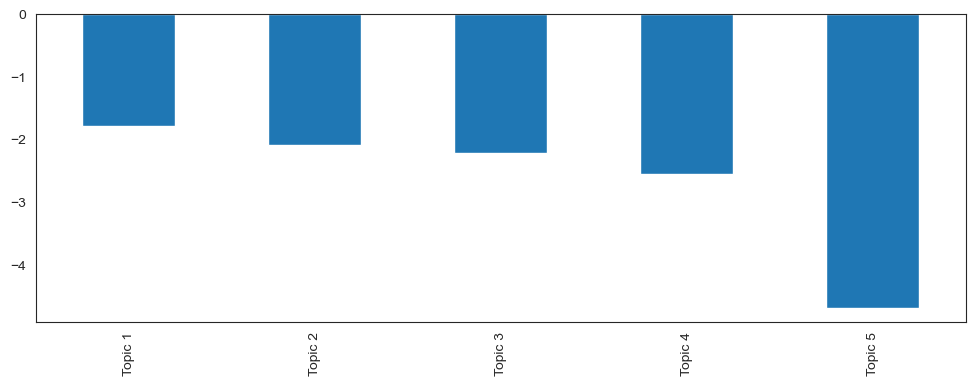

In [22]:
topic_coherence = []
topic_words = pd.DataFrame()
for t in range(len(coherence)):
    label = topic_labels[t]
    topic_coherence.append(coherence[t][1])
    df = pd.DataFrame(coherence[t][0], columns=[(label, "prob"), (label, "term")])
    df[(label, "prob")] = df[(label, "prob")].apply(lambda x: "{:.2%}".format(x))
    topic_words = pd.concat([topic_words, df], axis=1)

topic_words.columns = pd.MultiIndex.from_tuples(topic_words.columns)
pd.set_option("expand_frame_repr", False)
topic_words.head().to_csv("topic_words.csv", index=False)
print(topic_words.head())

pd.Series(topic_coherence, index=topic_labels).plot.bar(figsize=(12, 4));

### Using `gensim` `Dictionary` 

In [23]:
docs = [d.split() for d in train_docs.article.tolist()]
docs = [[t for t in doc if t not in stop_words] for doc in docs]

In [24]:
dictionary = Dictionary(docs)
dictionary.filter_extremes(no_below=min_df, no_above=max_df, keep_n=max_features)

In [25]:
corpus = [dictionary.doc2bow(doc) for doc in docs]

In [26]:
print("Number of unique tokens: %d" % len(dictionary))
print("Number of documents: %d" % len(corpus))

Number of unique tokens: 2000
Number of documents: 2175


In [27]:
num_topics = 5
chunksize = 500
passes = 20
iterations = 400
eval_every = None  # Don't evaluate model perplexity, takes too much time.

temp = dictionary[0]  # This is only to "load" the dictionary.
id2word = dictionary.id2token

In [28]:
model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    chunksize=chunksize,
    alpha="auto",
    eta="auto",
    iterations=iterations,
    num_topics=num_topics,
    passes=passes,
    eval_every=eval_every,
)

In [29]:
model.show_topics()

[(0,
  '0.012*"government" + 0.009*"Labour" + 0.008*"Blair" + 0.007*"public" + 0.006*"election" + 0.006*"say" + 0.006*"Brown" + 0.005*"Lord" + 0.005*"party" + 0.005*"says"'),
 (1,
  '0.008*"company" + 0.008*"market" + 0.006*"economic" + 0.006*"growth" + 0.006*"firm" + 0.006*"chief" + 0.006*"sales" + 0.006*"rise" + 0.006*"economy" + 0.005*"oil"'),
 (2,
  '0.009*"game" + 0.009*"win" + 0.007*"England" + 0.006*"good" + 0.006*"play" + 0.006*"think" + 0.006*"really" + 0.006*"it\'s" + 0.005*"got" + 0.005*"second"'),
 (3,
  '0.009*"mobile" + 0.009*"technology" + 0.009*"use" + 0.008*"music" + 0.007*"digital" + 0.007*"users" + 0.007*"games" + 0.006*"used" + 0.006*"net" + 0.006*"software"'),
 (4,
  '0.026*"best" + 0.020*"film" + 0.012*"won" + 0.009*"music" + 0.008*"director" + 0.008*"British" + 0.008*"including" + 0.007*"UK" + 0.007*"award" + 0.007*"actor"')]

### Evaluating Topic Assignments on the Test Set

In [30]:
docs_test = [d.split() for d in test_docs.article.tolist()]
docs_test = [[t for t in doc if t not in stop_words] for doc in docs_test]

test_dictionary = Dictionary(docs_test)
test_dictionary.filter_extremes(no_below=min_df, no_above=max_df, keep_n=max_features)
test_corpus = [dictionary.doc2bow(doc) for doc in docs_test]

In [31]:
gamma, _ = model.inference(test_corpus)
topic_scores = pd.DataFrame(gamma)
topic_scores.head(10)

,0,1,2,3,4
0,0.104061,8.534603,0.092732,2.684923,30.986446
1,7.482516,0.095756,15.561100,92.180717,0.056988
2,0.104094,13.613563,6.946664,109.654388,0.056988
3,17.337172,64.841904,0.092737,0.063132,0.056988
4,0.104077,5.059891,33.119961,0.063132,0.056988
5,0.104083,50.259331,51.782486,18.179918,0.056988
6,6.248022,108.132355,1.884751,0.063132,0.056988
7,0.104097,5.400244,100.747360,0.063132,0.056988
8,0.104066,75.370430,2.448648,3.407274,0.056988
9,0.104075,81.131119,4.038539,0.063132,0.056987


In [32]:
topic_probabilities = topic_scores.div(topic_scores.sum(axis=1), axis=0)
topic_probabilities.head()

,0,1,2,3,4
0,0.002454,0.201275,0.002187,0.063320,0.730765
1,0.064853,0.000830,0.134872,0.798952,0.000494
2,0.000798,0.104418,0.053282,0.841065,0.000437
3,0.210423,0.786993,0.001126,0.000766,0.000692
4,0.002710,0.131754,0.862408,0.001644,0.001484


In [33]:
topic_probabilities.idxmax(axis=1).head()

0    4
1    3
2    3
3    1
4    2
dtype: int64

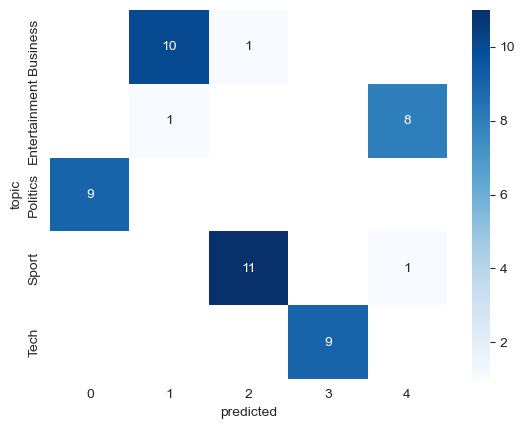

In [34]:
predictions = test_docs.topic.to_frame("topic").assign(
    predicted=topic_probabilities.idxmax(axis=1).values
)
heatmap_data = predictions.groupby("topic").predicted.value_counts().unstack()
sns.heatmap(heatmap_data, annot=True, cmap="Blues");

## Resources

- pyLDAvis: 
    - [Talk by the Author](https://speakerdeck.com/bmabey/visualizing-topic-models) and [Paper by (original) Author](http://www.aclweb.org/anthology/W14-3110)
    - [Documentation](http://pyldavis.readthedocs.io/en/latest/index.html)
- LDA:
    - [David Blei Homepage @ Columbia](http://www.cs.columbia.edu/~blei/)
    - [Introductory Paper](http://www.cs.columbia.edu/~blei/papers/Blei2012.pdf) and [more technical review paper](http://www.cs.columbia.edu/~blei/papers/BleiLafferty2009.pdf)
    - [Blei Lab @ GitHub](https://github.com/Blei-Lab)
    
- Topic Coherence:
    - [Exploring Topic Coherence over many models and many topics](https://www.aclweb.org/anthology/D/D12/D12-1087.pdf)
    - [Paper on various Methods](http://www.aclweb.org/anthology/N10-1012)
    - [Blog Post - Overview](http://qpleple.com/topic-coherence-to-evaluate-topic-models/)
